In [1]:
import os, sys, torch, time
import torch.nn.functional as F
import pandas as pd, re, random
import numpy as np
import scipy.signal as signal
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
sys.path.insert(0, r"c:\repos\DroneDetectionRF\NoisyUAV")
from modelos.cvcnn import ComplexConv1DNet
from funciones.cargador import cargar_muestra, NOMBRES_CLASES
from funciones.detector_entropia import detectar_bursts, plot_muestra, print_diagnostico, plot_espectrograma_3d

In [54]:
FS = 14e6
TARGET_DESEADO = 5      # 0=DJI, 1=FutabaT14, 2=FutabaT7, 3=Graupner,
                         # 5=Taranis, 6=Turnigy  |  None = cualquier dron
SNR_DESEADA    = -12     # dB, paso 2 desde -20 hasta 30  |  None = cualquiera

In [55]:
# 1. EMPAREJAMIENTO ESTRICTO CON LA DIVISIÓN DE TEST
CSV_METADATA = r"C:\TFM_data\NoisyUAV\stage2_norm\metadata_stage2.csv"
if not os.path.exists(CSV_METADATA):
    CSV_METADATA = r"C:\TFM_data\NoisyUAV\stage2\metadata_stage2.csv"
df = pd.read_csv(CSV_METADATA)
df_train, df_temp = train_test_split(df, test_size=0.30, stratify=df["label"], random_state=42)
df_val,   df_test = train_test_split(df_temp, test_size=0.50, stratify=df_temp["label"], random_state=42)
candidatos = df_test[df_test["label"] == 1].copy()   # solo drones
if TARGET_DESEADO is not None:
    candidatos = candidatos[candidatos["target"] == TARGET_DESEADO]
    if candidatos.empty:
        raise ValueError(f"❌ No hay muestras de target={TARGET_DESEADO} en el test set.")
if SNR_DESEADA is not None:
    candidatos = candidatos[candidatos["snr"] == SNR_DESEADA]
    if candidatos.empty:
        snrs_disponibles = sorted(df_test[df_test["label"] == 1]["snr"].unique())
        raise ValueError(
            f"❌ No hay muestras de target={TARGET_DESEADO} con SNR={SNR_DESEADA} dB.\n"
            f"   SNRs disponibles para este target: {snrs_disponibles}"
        )
nombre_clase = NOMBRES_CLASES.get(TARGET_DESEADO, f"target{TARGET_DESEADO}") if TARGET_DESEADO is not None else "cualquier dron"
print(f"✅ {len(candidatos)} candidatos encontrados → [{nombre_clase} | SNR={SNR_DESEADA} dB]")
# semilla_aleatoria = random.randint(0, 9999)
semilla_aleatoria = 4341
sample_seleccionado = candidatos.sample(1, random_state=semilla_aleatoria).iloc[0]
crop_id        = sample_seleccionado["crop_id"]
parent_filename = re.sub(r"_burst\d+\.pt$", ".pt", crop_id)
RUTA_RAW_PARENT = os.path.join(r"C:\TFM_data\NoisyUAV\drone_RF_data", parent_filename)
print("=" * 52)
print(f"🎬 Muestra Ciega Recuperada    : {parent_filename}, semilla {semilla_aleatoria}")
print(f"📡 Target : {sample_seleccionado['target']} ({nombre_clase})  |  SNR : {sample_seleccionado['snr']} dB")
print("=" * 52)
iq_tensor, _, original_target, original_snr = cargar_muestra(RUTA_RAW_PARENT)
print(f"✅ Tensor cargado: {iq_tensor.shape}")
# Extraer el array numpy compensado temporalmente
x = iq_tensor[0].numpy() + 1j * iq_tensor[1].numpy()

✅ 27 candidatos encontrados → [Taranis | SNR=-12 dB]
🎬 Muestra Ciega Recuperada    : IQdata_sample7987_target5_snr-12.pt, semilla 4341
📡 Target : 5 (Taranis)  |  SNR : -12.0 dB
✅ Tensor cargado: torch.Size([2, 1048576])


In [56]:
# ======================================================================
# ALGORITMO DETECTOR MME (Max-Min Eigenvalue) DE MATRIZ DE COVARIANZA
# ======================================================================
def detector_mme(x, L=16, N=1024, hop=512, fs=14e6):
    """
    Detector basado en Autovalores (Covariance Matrix - Eigenvalue Ratio).
    L: Factor de suavizado (Tamaño matriz de covarianza L x L)
    N: Número de muestras para estimar la matriz por cada paso temporal
    """
    n_samples = len(x)
    n_windows = (n_samples - N - L + 1) // hop
    
    ratios = np.zeros(n_windows)
    tiempos = np.zeros(n_windows)
    
    for i in range(n_windows):
        start = i * hop
        window_data = x[start : start + N + L - 1]
        
        # Construcción matricial super-rápida (Hankel-like) usando stride_tricks
        shape = (L, N)
        strides = (window_data.strides[0], window_data.strides[0])
        X = np.lib.stride_tricks.as_strided(window_data, shape=shape, strides=strides)
        
        # Matriz de covarianza empírica (L x L)
        R = (X @ X.conj().T) / N
        
        # Eigenvalues de matriz Hermítica (devueltos en orden ascendente)
        eigenvalues = np.linalg.eigvalsh(R)
        
        l_max = eigenvalues[-1]   # Autovalor Principal (Energía correlada)
        l_min = eigenvalues[0]    # Autovalor Mínimo (Piso de ruido inalterado)
        
        if l_min <= 1e-12:
            ratios[i] = 1.0
        else:
            ratios[i] = l_max / l_min
            
        tiempos[i] = (start + N / 2.0) / fs * 1000.0 # Posibilidad en ms
    return tiempos, ratios

In [57]:
# Ejecutamos el detector MME
print("⏳ Calculando AutoValores en dominio temporal...")
t0 = time.time()
tiempos_mme, ratios_mme = detector_mme(x, L=16, N=1024, hop=512)
print(f"✅ AutoValores calculados en {time.time()-t0:.3f} segundos")
# Lógica de detección (Umbral = P90 del ratio + 3*MAD)
mad_ratios = np.median(np.abs(ratios_mme - np.median(ratios_mme)))
umbral_mme = np.percentile(ratios_mme, 90) + 3.0 * mad_ratios
activaciones = ratios_mme > umbral_mme
# Agrupando activaciones contiguas en cajas de burst (micro-ráfagas)
bursts_mme = []
en_burst = False
start_t = 0
for i, activo in enumerate(activaciones):
    if activo and not en_burst:
        en_burst = True
        start_t = tiempos_mme[i]
    elif not activo and en_burst:
        en_burst = False
        end_t = tiempos_mme[i-1]
        if end_t - start_t > 0.1: # Filtro temporal minimo (0.1ms)
            bursts_mme.append((start_t, end_t))
if en_burst:
    bursts_mme.append((start_t, tiempos_mme[-1]))

⏳ Calculando AutoValores en dominio temporal...
✅ AutoValores calculados en 0.407 segundos


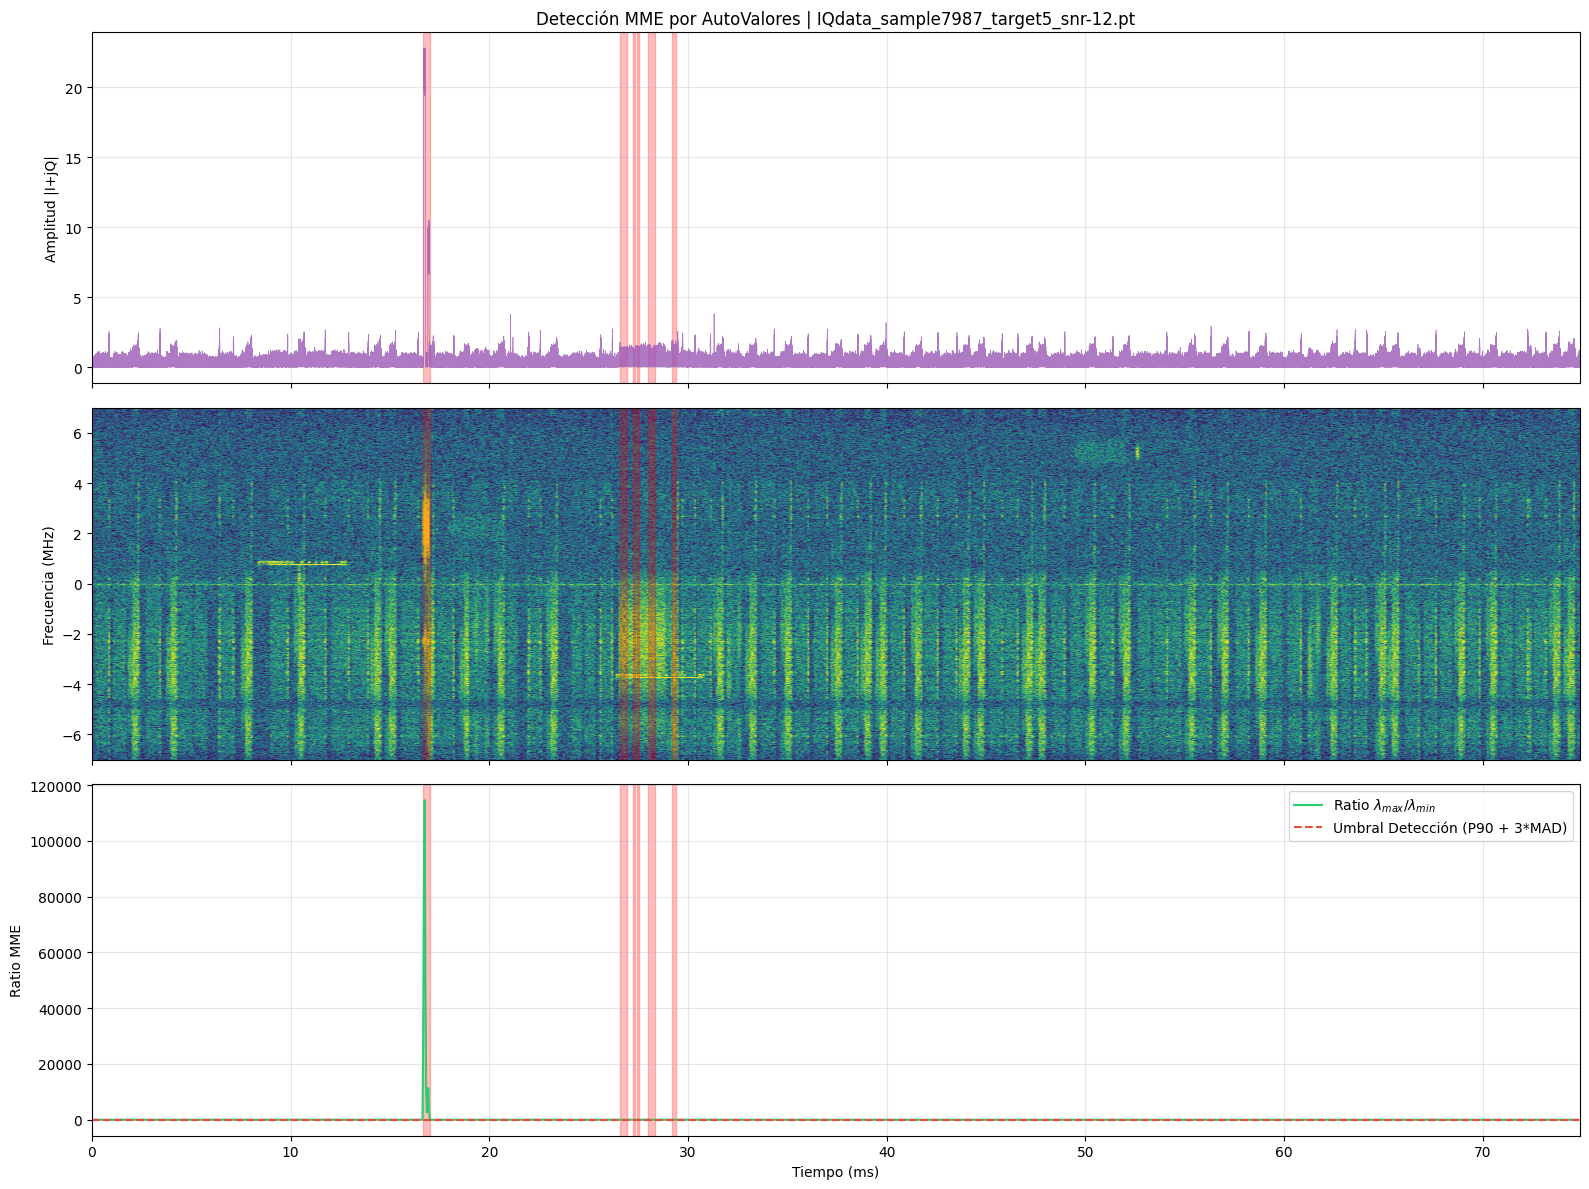

🎯 Resumen MME: 6 ráfagas (bursts) identificadas.


In [58]:
# ======================================================================
# GRAFICACIÓN (Baseband | Espectrograma | Ratio MME)
# ======================================================================
fig, ax = plt.subplots(3, 1, figsize=(16, 12), sharex=True)
tiempo_total = np.arange(len(x)) / FS * 1000
# 1. Amplitud Baseband
ax[0].plot(tiempo_total, np.abs(x), color='#9b59b6', alpha=0.8, linewidth=0.5)
ax[0].set_ylabel("Amplitud |I+jQ|")
ax[0].set_title(f"Detección MME por AutoValores | {parent_filename}")
ax[0].grid(True, alpha=0.3)
# 2. Espectrograma
f_st, t_st, Zxx = signal.stft(x, fs=FS, nperseg=2048, return_onesided=False)
f_st = np.fft.fftshift(f_st) / 1e6
P_db = 10 * np.log10(np.abs(np.fft.fftshift(Zxx, axes=0))**2 + 1e-12)
t_st_ms = t_st * 1000
ax[1].pcolormesh(t_st_ms, f_st, P_db, shading='gouraud', cmap='viridis', 
                 vmin=np.percentile(P_db, 5), vmax=np.percentile(P_db, 99.5))
ax[1].set_ylabel("Frecuencia (MHz)")
# 3. Ratio Eigenvalues (MME)
ax[2].plot(tiempos_mme, ratios_mme, color='#2ecc71', label='Ratio $λ_{max} / λ_{min}$')
ax[2].axhline(umbral_mme, color='#e74c3c', linestyle='--', label='Umbral Detección (P90 + 3*MAD)')
ax[2].set_xlabel("Tiempo (ms)")
ax[2].set_ylabel("Ratio MME")
ax[2].grid(True, alpha=0.3)
ax[2].legend()
# Pintar las cajas de detección en rojo translucido en los 3 gráficos
for b in bursts_mme:
    for i in range(3):
        ax[i].axvspan(b[0], b[1], color='red', alpha=0.25)
        
plt.tight_layout()
plt.show()
print(f"🎯 Resumen MME: {len(bursts_mme)} ráfagas (bursts) identificadas.")